# Wiskundig modelleren van de groei van de populatie nijlpaarden van Escobar

## Modelleren m.b.v. een wiskundige functie

### De gegevens

In [1]:
# nodige modules importeren
import numpy as np                         # om te rekenen
import matplotlib.pyplot as plt            # om te tekenen
from scipy.optimize import curve_fit       # om regressie te kunnen uitvoeren

### Best passende rechte of kromme bij een dataset

Misschien maakte je al kennis met spreidingsdiagrammen en regressielijnen. De hier gegeven code is al wat je nodig hebt op daarmee aan de slag te gaan.  

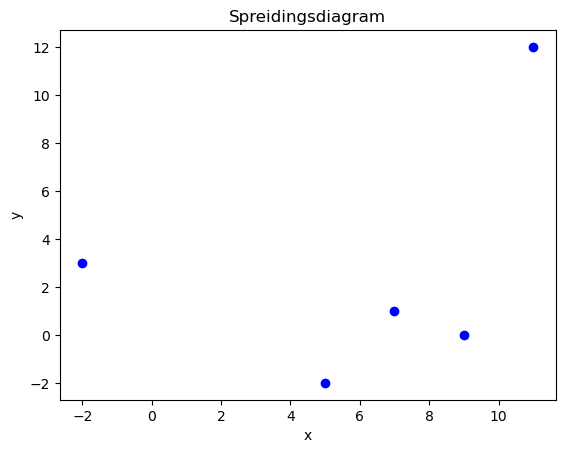

In [2]:
# spreidingsdiagram
x = np.array([-2, 5, 7, 9, 11])
y = np.array([3, -2, 1, 0, 12])              

plt.title("Spreidingsdiagram") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.scatter(x, y, marker ="o", color="blue")

plt.show()

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45]


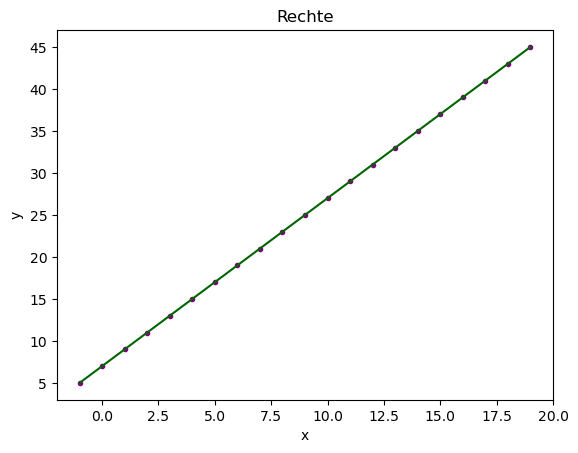

In [3]:
# grafiek van een rechte
x2 = np.arange(-1, 20, 1)     # genereer x-waarden in[-1, 20[ in stappen van 1
y2 = 2 * x2 + 7
print(x2)
print(y2)

plt.title("Rechte") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.scatter(x2, y2, marker =".", color="purple")
plt.plot(x2, y2, color="darkgreen")

plt.show()

In [4]:
# lineaire regressie, nodige functies
def rechte(x, a, b):
    """Voorschrift (schuine) rechte met variabele x en coëfficiënten a en b."""
    return a * x + b

def linreg(x, y):
    """Rechte best passend bij data x en y."""
    popt, pcov = curve_fit(rechte, x, y)         # curve_fit kijkt in def rechte() hoe die functie eruit ziet
    # curve_fit geeft twee zaken terug, waaraan gerefereerd wordt met popt en pcov
    # enkel popt nodig; popt is een koppel dat de coëfficiënten a en b van gezochte rechte bevat
    a, b =  popt      # eerste element van popt is a en tweede element is b
    print("y = ", a, "x +", b)      # toon voorschrift
    return a, b                                 # geeft parameters terug uit vergelijking exponentiële functie

y =  0.3899999999986695 x + 0.4599999999988229
[-0.32  2.41  3.19  3.97  4.75]


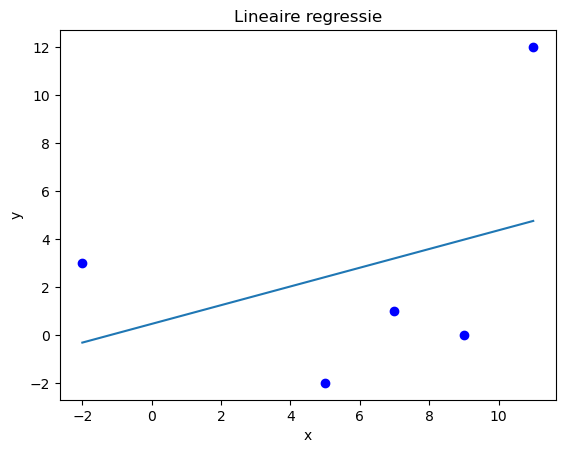

In [5]:
# lineaire regressie uitvoeren
a, b = linreg(x, y)
y_regressielijn = rechte(x, a, b)                   
# y_regressielijn verwijst naar lijst y-waarden van punten gelegen op regressielijn 
# om die y-waarden te berekenen wordt er vertrokken van de bgekende x-waarden
# die x-waarden worden ingevuld in uitdrukking a x + b
print(y_regressielijn)           

plt.title("Lineaire regressie") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.scatter(x, y, marker ="o", color="blue")
plt.plot(x, y_regressielijn)
plt.show()

In [6]:
# kwadratische regressie, nodige functies
def parabool(x, a, b, c):
    """Voorschrift tweedegraadsfunctie met variabele x en coëfficiënten a, b en c."""
    return a * x**2 + b * x + c

def kwadreg(x, y):
    """Parabool best passend bij data x en y."""
    popt, pcov = curve_fit(parabool, x, y)         # curve_fit kijkt in def rechte() hoe die functie eruit ziet
    # curve_fit geeft twee zaken terug, waaraan gerefereerd wordt met popt en pcov
    # enkel popt nodig; popt is een drietal dat de coëfficiënten a, b en c van gezochte parabool bevat
    a, b, c =  popt      # eerste element van popt is a, tweede element is b en derde is c
    print("y = ", a, "x^2 +", b, "x +", c)      # toon voorschrift
    return a, b, c                              # geeft parameters terug uit vergelijking exponentiële functie

y =  0.23302387267737246 x^2 + -1.5674005305095817 x + -0.8449336870066546
[ 3.22196286 -2.85633952 -0.39856764  3.92339523 10.10954907]


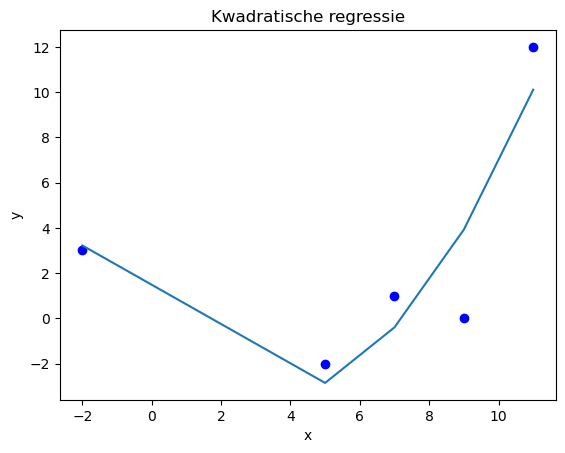

In [7]:
# kwadratische regressie uitvoeren
a, b, c = kwadreg(x, y)
y_regressiekromme = parabool(x, a, b, c)                   
# y_regressiekromme verwijst naar lijst y-waarden van punten gelegen op regressiekromme 
# om die y-waarden te berekenen wordt er vertrokken van de gekende x-waarden
# die x-waarden worden ingevuld in uitdrukking a x^2 + b x + c
print(y_regressiekromme)           

plt.title("Kwadratische regressie") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.scatter(x, y, marker ="o", color="blue")
plt.plot(x, y_regressiekromme)
plt.show()

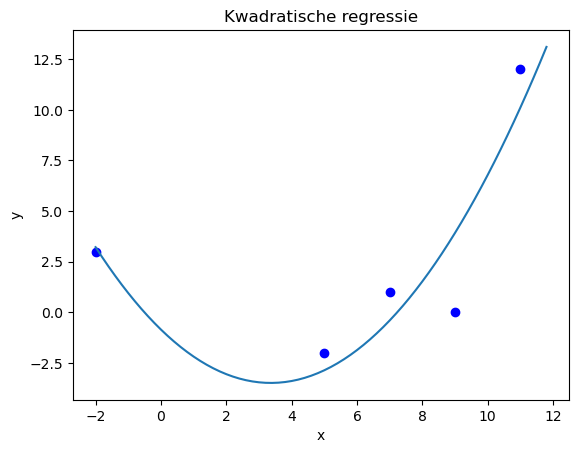

In [8]:
# grafiek beter maken, gezochte parabool ziet er niet uit als een parabool
# om vloeiende parabool te tekenen genoeg punten nodig
x_meer = np.arange(-2, 12, 0.2)
# print(x_meer)
y_regressiekromme = parabool(x_meer, a, b, c)                   
# y_regressiekromme verwijst naar lijst y-waarden van punten gelegen op regressiekromme 
# om die y-waarden te berekenen wordt er vertrokken van de gekende x_meer-waarden
# die x_meer-waarden worden ingevuld in uitdrukking a x^2 + b x + c
# print(y_regressiekromme)           

plt.title("Kwadratische regressie") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.scatter(x, y, marker ="o", color="blue")
plt.plot(x_meer, y_regressiekromme)
plt.show()

### De cocaïnenijlpaardenpopulatie

Gegeven:

| Jaartal | Aantal nijlpaarden |
| --------| :-----------------:|
| 1994    |  4     |
| 2006    | 16     |
| 2009    | 28     |
| 2014    | 50     |
| 2016    | 60     |
| 2020    | 75     |

In [9]:
# voorbeeldcode
# gegevens populatie
jaartal = np.array([1994, 2006, 2009, 2014, 2016, 2020])
aantal_nijlpaarden = np.array([4, 16, 28, 50, 60, 75])

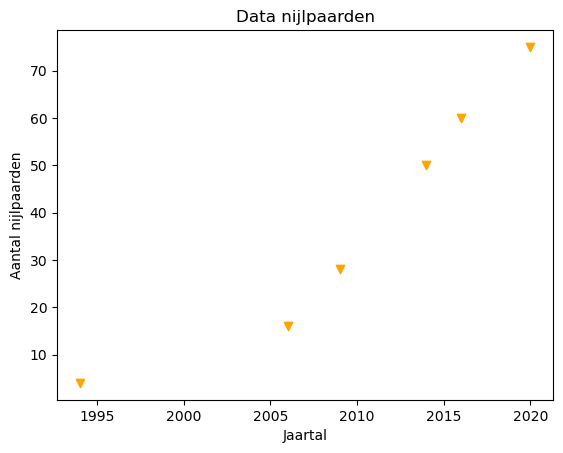

In [10]:
# voorbeeldcode
# spreidingsdiagram

plt.title("Data nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal, aantal_nijlpaarden, marker ="v", color="orange")

plt.show()

Het spreidingsdiagram doet **exponentiële groei** vermoeden. <br>
Het voorschrift van zo'n functie ziet eruit als volgt:
$$ y = b \cdot a^x,$$
met $a$ de groeifactor.<br> 
Je zal de parameters $a$ en $b$ moeten bepalen.

### Waarde van *b*

$b$ komt overeen met de functiewaarde voor $x = 0$.

Vraag: 
- Welk jaartal laat je overeenkomen met die waarde $0$?
- Wat is de waarde van *b*?

Antwoord:

Antwoord: 0 komt overeen met 1994, dus $b = 4$. 

### Groeifactor per jaar schatten

Van 4 nijlpaarden naar 16 nijlpaarden in de periode 1994 tot 2006 -> factor 4 over 12 jaar.

In [11]:
# voorbeeldcode
4**(1/12)

1.122462048309373

In [12]:
(7/4)**(1/3)

1.205071132087615

In [13]:
(25/14)**(1/5)

1.1229551070568211

In [14]:
(6/5)**(1/2)

1.0954451150103321

In [15]:
(5/4)**(1/4)

1.057371263440564

Op basis van deze berekeningen kan je de groei schatten, bv. ergens tussen 5 en 21 %.

### Een wiskundig model

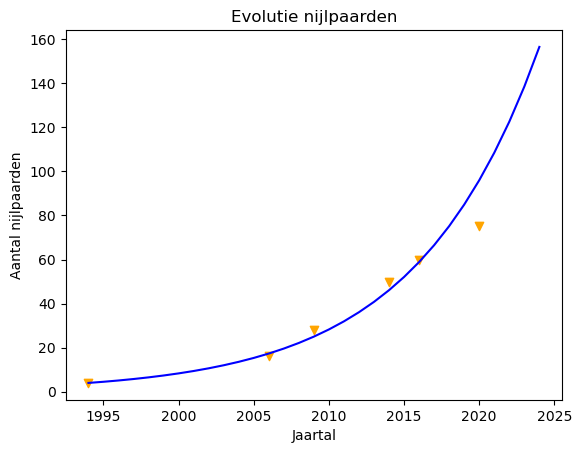

In [16]:
# voorbeeldcode
# bijvoorbeeld een aangroei van 13 % per jaar
x = np.arange(1994,2025)
y = 4 * 1.13**(x-1994)               # de grafiek van de regressielijn moet 1994 eenheden opschuiven naar rechts

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal, aantal_nijlpaarden, marker ="v", color="orange")
plt.plot(x, y, color="blue")

plt.show()

Je kan ook op een andere manier de groeifactor schatten, bv. door het gemiddelde te nemen van de berekende groeifactoren.

In [17]:
# voorbeeldcode
np.mean([4**(1/12), (7/4)**(1/3), (25/14)**(1/5), (6/5)**(1/2), (5/4)**(1/4)])

1.1206609331809412

Je kan jouw schatting nog aftoetsen aan de populatiegroei over de periode van 1994 tot 2020.

In [18]:
# voorbeeldcode
(75/4)**(1/26)

1.1193388754569054

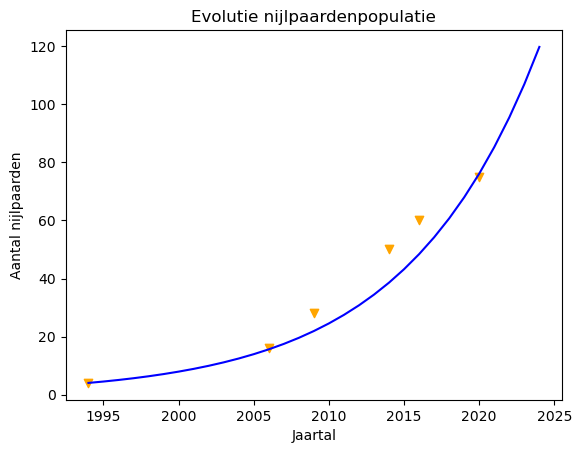

In [19]:
# voorbeeldcode
x = np.arange(1994,2025)
y = 4 * 1.12**(x-1994)

plt.title("Evolutie nijlpaardenpopulatie") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal, aantal_nijlpaarden, marker ="v", color="orange")
plt.plot(x, y, color="blue")

plt.show()

### Modelleren a.d.h.v. regressie

Je kan ook regressie uitvoeren m.b.v. Python.<br>
Je zorgt er eerst voor dat de nodige functies beschikbaar zijn (zie ook notebooks over regressie van Python in de wiskundeles en de notebook over exponentiële regressie uit Epidemie van Python in STEM).

In [20]:
# voorbeeldcode
# expreg 
def exp(x, a, b):
    """Voorschrift exponentiële functie."""
    return b * a**x 

def expreg(x, y):
    """Best passende kromme bepalen."""
    popt, pcov = curve_fit(exp, x, y)         # curve_fit kijkt in def exp() hoe die functie eruit ziet
    # curve_fit geeft twee zaken terug, waaraan gerefereerd wordt met popt en pcov
    # enkel popt nodig; popt is een koppel dat de parameters a en b van gezochte exponentiële functie bevat
    a =  popt[0]
    b =  popt[1]
    print("y =", b, "*", a, "**x voor periode", x)      # toon voorschrift
    return a, b                                 # geeft parameters terug uit vergelijking exponentiële functie


In [21]:
# voorbeeldcode
# de grote getallen in jaartal leveren problemen op bij het gebruik van de functies
# die getallen verkleinen door overal 1994 van af te trekken
x1 = jaartal - 1994
print(x1)

[ 0 12 15 20 22 26]


In [22]:
# voorbeeldcode
# exponentiële regressie uitvoeren
a1, b1 = expreg(x1, aantal_nijlpaarden)
y1_regressielijn = exp(x1, a1, b1) 

y = 7.0717327800909375 * 1.0974338502285652 **x voor periode [ 0 12 15 20 22 26]


Vraag: Wat is in dit model de procentuele groei per jaar? 

Antwoord: 

Antwoord: Volgends dit model groeit de nijlpaardenpopulatie met ongeveer 9,7 % per jaar. 

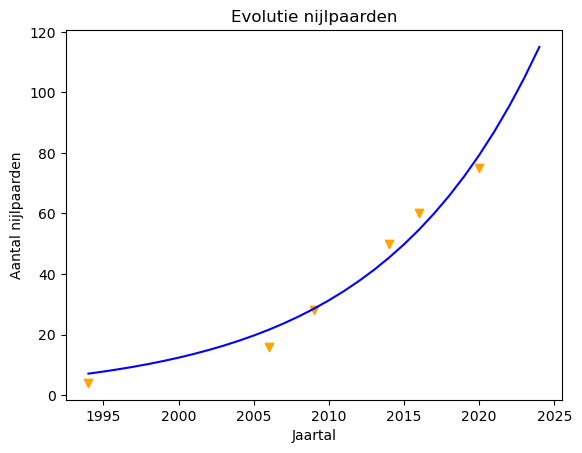

In [23]:
# voorbeeldcode
x = np.arange(1994,2025)
y = exp(x-1994, a1, b1)  # de grafiek van de regressielijn moet 1994 eenheden opschuiven naar rechts

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal, aantal_nijlpaarden, marker ="v", color="orange")
plt.plot(x, y, color="blue")

plt.show()


Vraag: Hoeveel nijlpaarden zouden er volgens dit model zijn in 2035 en in 2050?

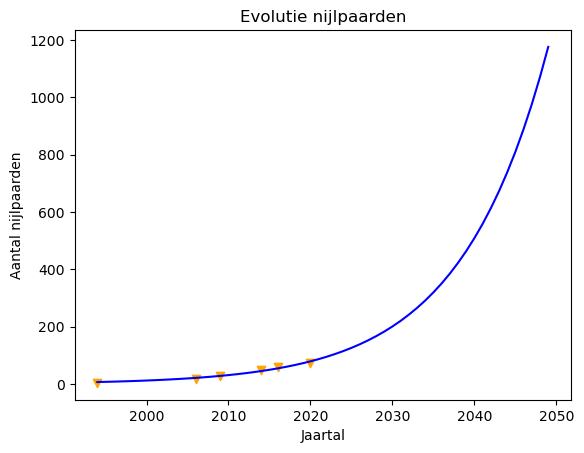

In [24]:
# voorbeeldcode
x_vraag = np.arange(1994,2050)
y_vraag = exp(x_vraag-1994, a1, b1)  # de grafiek van de regressielijn moet 1994 eenheden opschuiven naar rechts

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal, aantal_nijlpaarden, marker ="v", color="orange")
plt.plot(x_vraag, y_vraag, color="blue")

plt.show()

In [25]:
# voorbeeldcode
y_2035 = exp(2035-1994, a1, b1)
y_2050 = exp(2050-1994, a1, b1)
print(y_2035, y_2050)

319.91769846858745 1290.3678807616743


Antwoord: 

Antwoord: Dit model voorspelt 320 nijlpaarden in 2035 en 1290 nijlpaarden in 2050.

## Geschat aantal in 2021

In 2021 was de populatie naar schatting aangegroeid tot 111 exemplaren. 
- Bekijk of het bijkomende datapunt op de gevonden regressielijn past.
- Als je de regressie opnieuw zou uitvoeren met de aangevulde data, houdt de vorige groeifactor dan stand? 

In [26]:
# voorbeeldcode
y_2021 = exp(2021-1994, a1, b1)
print(y_2021)

87.0445012311228


Antwoord: Het model geeft 87 nijlpaarden in 2021 wat heel wat minder is dan de geschatte 111.

Antwoord:

In [27]:
# voorbeeldcode
# data populatie
jaartal_aangevuld = np.array([1994, 2006, 2009, 2014, 2016, 2020, 2021])
aantal_nijlpaarden_aangevuld = np.array([4, 16, 28, 50, 60, 75, 110])

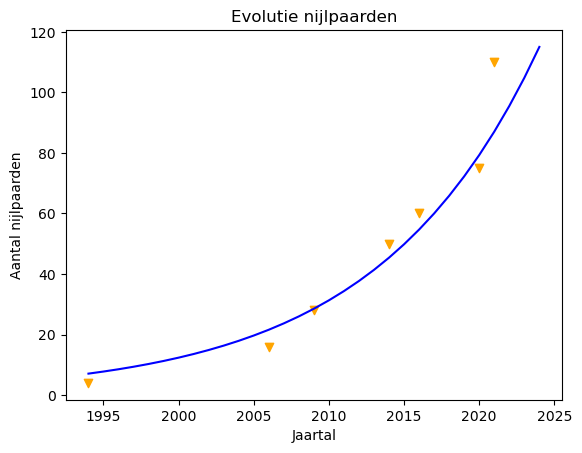

In [28]:
# voorbeeldcode
# grafische voorstelling

# x = np.arange(1994,2025)
# y = exp(x-1994, a1, b1)  # de grafiek van de regressielijn moet 1994 eenheden opschuiven naar rechts

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal_aangevuld, aantal_nijlpaarden_aangevuld, marker ="v", color="orange")
plt.plot(x, y, color="blue")

plt.show()


In [29]:
# regressie opnieuw uitvoeren

x2 = jaartal_aangevuld - 1994
print(x2)

a2, b2 = expreg(x2, aantal_nijlpaarden_aangevuld)
y2_regressielijn = exp(x2, a2, b2) 

[ 0 12 15 20 22 26 27]
y = 5.108471304926809 * 1.1164059561818196 **x voor periode [ 0 12 15 20 22 26 27]


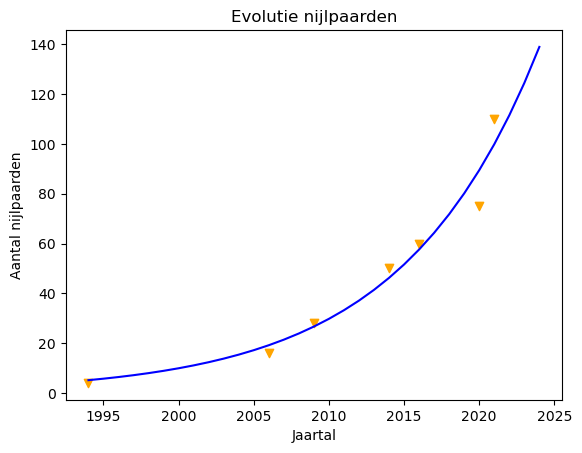

In [30]:
# voorbeeldcode
# grafische voorstelling

# x = np.arange(1994,2025)
y_nieuw = exp(x-1994, a2, b2)  # de grafiek van de regressielijn moet 1994 eenheden opschuiven naar rechts

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(jaartal_aangevuld, aantal_nijlpaarden_aangevuld, marker ="v", color="orange")
plt.plot(x, y_nieuw, color="blue")

plt.show()


Antwoord:

Antwoord: Het groeipercentage is aangepast naar boven. Er wordt nu uitgegaan van een groei van 11,6 % per jaar.

In [31]:
# voorbeeldcode
y_2035_2 = exp(2035-1994, a2, b2)
y_2050_2 = exp(2050-1994, a2, b2)
print(y_2035_2, y_2050_2)

466.65819495655205 2434.05882335669


Antwoord:

Antwoord: Met deze aanpassingen wordt er in 2035 een populatie voorspeld van 467 exemplaren en in 2050 2434 nijlpaarden.